# cm3015 machine learning and neural networks mid-term coursework

## network intrusion detection using classical machine learning
**Student Name:** Vishal Theerthagiri  
**Student ID:** 240285463  
**Date:** July 11, 2026

this project investigates whether classical machine learning algorithms can distinguish between benign and malicious network traffic using a balanced cicids2017-based dataset.

the classification task is binary:

- `0` = benign network traffic
- `1` = attack / malicious network traffic

the project compares the following algorithms:

- naive majority-class baseline
- k-nearest neighbours classifier implemented from scratch
- decision tree classifier
- pca-assisted versions of the models

the main evaluation metrics are accuracy, precision, recall, f1-score, and confusion matrix analysis. recall and f1-score are especially important because intrusion detection systems should minimise missed attacks while still avoiding excessive false alarms.

## abstract

this project compares classical machine learning algorithms for binary network intrusion detection using a balanced cicids2017-based dataset. the aim is to evaluate whether benign and malicious network flows can be separated using flow-level numerical features. a naive majority-class baseline, a k-nearest neighbours classifier implemented from scratch, decision tree classifiers with different maximum depths, and pca-assisted variants were tested. the baseline achieved 50% accuracy and an f1-score of 0 for the attack class, confirming that a non-learning approach is inadequate. the best scratch knn model achieved an f1-score of approximately 0.977, while the decision tree with maximum depth 10 achieved an f1-score of approximately 0.994. an unconstrained decision tree achieved the highest f1-score of approximately 0.997, but depth 10 was selected for detailed analysis because it offers strong performance with better control over overfitting. pca reduced the feature space from 52 features to 18 components while retaining about 95.18% of variance. overall, the results suggest that classical machine learning methods, especially decision trees, can perform strongly on this balanced intrusion detection task. additional error analysis, sample-size sensitivity testing, cross-validation, and bootstrap confidence intervals support the reliability of the selected depth 10 decision tree.

## 1. introduction

network intrusion detection is the task of identifying malicious activity within network traffic. traditional rule-based systems can detect known attacks, but they may struggle when traffic patterns change or when attacks do not exactly match existing signatures. machine learning offers an alternative approach by learning patterns directly from historical network-flow data.

this project focuses on binary intrusion detection, where each network flow is classified as either benign or malicious. this is a relevant machine learning problem because network-flow datasets usually contain many numerical features, such as packet lengths, flow duration, inter-arrival times, and header information. these features can be used by classification algorithms to learn differences between normal and attack traffic.

the aim of this project is to compare classical machine learning algorithms from the module, rather than deep learning methods. the selected algorithms are k-nearest neighbours, decision trees, and principal component analysis. knn is implemented from scratch to demonstrate understanding of the algorithmic process. decision trees are used because they are fast, interpretable, and suitable for tabular numerical data. pca is used to test whether dimensionality reduction can reduce the feature space while preserving predictive performance.

this problem is grounded in the wider network intrusion detection literature. the dataset used in this project is derived from cic-ids2017, introduced by sharafaldin, habibi lashkari and ghorbani (2018), who generated the traffic captures and proposed the original flow-based feature set that later became a standard benchmark in this field. prior systematic benchmarking of classical machine learning methods on cic-ids2017, such as the large-scale comparison of 31 anomaly-based intrusion detection models by maseer et al. (2021), has shown that tree-based and distance-based classifiers typically achieve f1-scores in the region of 0.90-1.00 on this dataset, while also highlighting that reported performance varies considerably with preprocessing choices, feature subsets, and the degree of class balancing applied. this project's results are compared against that context in the evaluation section.


## 2. background

### k-nearest neighbours

k-nearest neighbours is a supervised classification algorithm based on distance. during training, knn stores the training examples rather than learning explicit model parameters. during prediction, it calculates the distance between a new example and the stored training examples, selects the k closest neighbours, and predicts the most common class among them.

in this project, euclidean distance is used. because euclidean distance is affected by feature scale, standardisation is applied before knn. a limitation of knn is that prediction can be slow for large datasets because every test example must be compared with many stored training examples.

### decision tree classifier

a decision tree classifies examples by repeatedly splitting the data using threshold-based rules. at each split, the algorithm chooses a feature and threshold that separates the classes as effectively as possible. decision trees are useful because they are interpretable and work well on tabular data.

however, very deep trees may overfit because they can learn overly specific patterns from the training data. for this reason, this project compares decision trees with maximum depths of 3, 5, 10, and no depth limit.

### principal component analysis

principal component analysis is an unsupervised dimensionality reduction technique. it transforms the original features into a smaller set of principal components that preserve as much variance as possible. pca can reduce runtime and remove redundancy between correlated features.

pca does not use class labels, so preserving variance does not always mean preserving the best information for classification. therefore, pca-assisted models are compared against models trained using the original features.

### evaluation metrics

accuracy measures the proportion of correct predictions, but it can be misleading if one class dominates. precision measures how many predicted attacks were truly attacks. recall measures how many actual attacks were detected. f1-score combines precision and recall into one metric. for intrusion detection, recall and f1-score are especially important because missed attacks are costly.
the binary classification metrics are computed as follows:

$$accuracy = \frac{tp + tn}{tp + tn + fp + fn}$$

$$precision = \frac{tp}{tp + fp}$$

$$recall = \frac{tp}{tp + fn}$$

$$f1 = 2 \times \frac{precision \times recall}{precision + recall}$$

where `tp` is true positives, `tn` is true negatives, `fp` is false positives, and `fn` is false negatives. in this project, the positive class is attack traffic. this means false negatives are particularly important because they represent attacks that the model missed.
### mathematical formalism

for a test point $x$ and training point $x_i$ with $p$ features, knn in this project uses the euclidean distance

$$d(x, x_i) = \sqrt{\sum_{j=1}^{p} (x_j - x_{i,j})^2}$$

the predicted class is the majority label among the $k$ training points with the smallest $d(x, x_i)$.

for the decision tree, each split is chosen to minimise class impurity in the resulting child nodes. this project's tree (scikit-learn's default) uses gini impurity

$$G(t) = 1 - \sum_{c=1}^{C} p(c \mid t)^2$$

where $p(c \mid t)$ is the proportion of class $c$ examples at node $t$. at each candidate split, the algorithm evaluates the weighted impurity of the two child nodes and selects the feature/threshold pair that produces the largest reduction in impurity. trees are grown recursively until a stopping criterion, such as `max_depth`, is reached (hastie, tibshirani and friedman, 2009).

for pca, given the standardised feature matrix $X$, the technique finds the eigenvectors $v_1, \dots, v_p$ of the covariance matrix $\Sigma = \frac{1}{n-1}X^TX$, ordered by their eigenvalues $\lambda_1 \geq \lambda_2 \geq \dots \geq \lambda_p$. projecting $X$ onto the top $k$ eigenvectors gives the principal components that retain the largest possible share of variance, $\sum_{i=1}^{k}\lambda_i \big/ \sum_{i=1}^{p}\lambda_i$, achievable by any $k$-dimensional linear projection (bishop, 2006).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

random_seed = 42
np.random.seed(random_seed)

## 3. methodology
### experimental design summary

| experiment | purpose | model / technique | related section |
|---|---|---|---|
| baseline | minimum benchmark | majority-class prediction | 3.3 |
| scratch knn | from-scratch algorithm implementation | k = 3, 5, 7 | 3.4 |
| decision tree depth comparison | test model complexity and overfitting | max_depth = 3, 5, 10, none | 3.5 |
| cross-validation | check result stability | depth 10 decision tree, 5-fold cv | 3.5 |
| pca experiment | test dimensionality reduction | pca retaining 95% variance | 3.6 |
| roc / pr analysis | inspect threshold behaviour | depth 10 decision tree | 4.1 |
| error analysis | inspect misclassified flows | false positives and false negatives | 4.2 |
### 3.1 dataset loading and initial inspection
the methodology follows a supervised classification workflow. first, the balanced cicids2017-based dataset is loaded and inspected. the target variable is separated from the input features, and the dataset is checked for missing values, infinite values, duplicates, and class balance. a balanced 60,000-row sample is then used for the experiments to keep runtime manageable, especially for the scratch knn implementation. the data is split into training and test sets using stratified sampling so that both sets preserve the 50:50 class balance. feature scaling is applied before knn and pca because both methods are sensitive to feature magnitude.

In [2]:
data_path = "cicids2017_binary_balanced.csv"

df = pd.read_csv(data_path)

print("dataset shape:", df.shape)
df.head()

dataset shape: (851388, 53)


,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack_Binary
0,80,5121659,3,12,6,0,4.0,3.464102,0,0,...,17922,2,20,0.0,0,0,0.0,0,0,0
1,53,128476,1,53,53,53,53.0,0.000000,116,116,...,-1,0,32,0.0,0,0,0.0,0,0,0
2,53,23701,1,53,53,53,53.0,0.000000,69,69,...,-1,0,32,0.0,0,0,0.0,0,0,0
3,54549,4,2,0,0,0,0.0,0.000000,0,0,...,-1,0,20,0.0,0,0,0.0,0,0,0
4,53,252129,1,58,58,58,58.0,0.000000,202,202,...,-1,0,32,0.0,0,0,0.0,0,0,0


In [3]:
df["Attack_Binary"].value_counts()

Attack_Binary
0    425694
1    425694
Name: count, dtype: int64

In [4]:
dataset_summary = pd.DataFrame({
    "rows": [df.shape[0]],
    "columns": [df.shape[1]],
    "feature_columns": [df.shape[1] - 1],
    "target_column": ["Attack_Binary"],
    "missing_values": [df.isna().sum().sum()],
    "duplicate_rows": [df.duplicated().sum()]
})

dataset_summary

,rows,columns,feature_columns,target_column,missing_values,duplicate_rows
0,851388,53,52,Attack_Binary,0,8


### 3.2 data preparation

In [5]:
target_col = "Attack_Binary"

X = df.drop(columns=[target_col])
y = df[target_col]

print("feature matrix shape:", X.shape)
print("target shape:", y.shape)
print("target distribution:")
print(y.value_counts(normalize=True))

feature matrix shape: (851388, 52)
target shape: (851388,)
target distribution:
Attack_Binary
0    0.5
1    0.5
Name: proportion, dtype: float64


In [6]:
print("missing values:", X.isna().sum().sum())
print("infinite values:", np.isinf(X.to_numpy()).sum())
print("duplicate rows:", df.duplicated().sum())

missing values: 0
infinite values: 0
duplicate rows: 8


In [7]:
sample_size = 60000

combined = pd.concat([X, y.rename("target")], axis=1)

combined_sample = (
    combined
    .groupby("target", group_keys=False)
    .sample(n=sample_size // 2, random_state=random_seed)
)

X_sample = combined_sample.drop(columns=["target"])
y_sample = combined_sample["target"]

print("sample shape:", X_sample.shape)
print("sample target distribution:")
print(y_sample.value_counts())
print(y_sample.value_counts(normalize=True))

sample shape: (60000, 52)
sample target distribution:
target
0    30000
1    30000
Name: count, dtype: int64
target
0    0.5
1    0.5
Name: proportion, dtype: float64


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sample,
    y_sample,
    test_size=0.30,
    random_state=random_seed,
    stratify=y_sample
)

print("training set:", X_train.shape)
print("test set:", X_test.shape)
print("training target distribution:")
print(y_train.value_counts(normalize=True))

training set: (42000, 52)
test set: (18000, 52)
training target distribution:
target
1    0.5
0    0.5
Name: proportion, dtype: float64


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("scaled training mean:", round(X_train_scaled.mean(), 4))
print("scaled training std:", round(X_train_scaled.std(), 4))

scaled training mean: -0.0
scaled training std: 1.0


### 3.3 naive baseline model

In [10]:
majority_class = y_train.mode()[0]

baseline_preds = np.full(shape=len(y_test), fill_value=majority_class)

baseline_results = {
    "model": "naive majority baseline",
    "accuracy": accuracy_score(y_test, baseline_preds),
    "precision": precision_score(y_test, baseline_preds, zero_division=0),
    "recall": recall_score(y_test, baseline_preds, zero_division=0),
    "f1_score": f1_score(y_test, baseline_preds, zero_division=0),
    "runtime_seconds": 0
}

baseline_results

{'model': 'naive majority baseline',
 'accuracy': 0.5,
 'precision': 0.0,
 'recall': 0.0,
 'f1_score': 0.0,
 'runtime_seconds': 0}

### 3.4 k-nearest neighbours implemented from scratch


In [11]:
class ScratchKNN:
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X_train = np.asarray(X)
        self.y_train = np.asarray(y).astype(int)

    def predict_one(self, x):
        distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
        nearest_indices = np.argsort(distances)[:self.k]
        nearest_labels = self.y_train[nearest_indices]

        class_counts = np.bincount(nearest_labels)
        return np.argmax(class_counts)

    def predict(self, X):
        X = np.asarray(X)
        predictions = [self.predict_one(row) for row in X]
        return np.array(predictions)

a smaller subset of 5,000 training examples and 2,000 test examples is used for scratch knn because the algorithm compares each test example against all stored training examples. this keeps the experiment practical while still demonstrating the algorithm from first principles.

In [12]:
knn_train_size = 5000
knn_test_size = 2000

X_knn_train = X_train_scaled[:knn_train_size]
y_knn_train = y_train.iloc[:knn_train_size]

X_knn_test = X_test_scaled[:knn_test_size]
y_knn_test = y_test.iloc[:knn_test_size]

print("knn training subset:", X_knn_train.shape)
print("knn test subset:", X_knn_test.shape)

knn training subset: (5000, 52)
knn test subset: (2000, 52)


In [13]:
knn_results = []

for k in [3, 5, 7]:
    start_time = time.time()

    knn = ScratchKNN(k=k)
    knn.fit(X_knn_train, y_knn_train)
    knn_preds = knn.predict(X_knn_test)

    runtime = time.time() - start_time

    knn_results.append({
        "model": f"scratch knn k={k}",
        "accuracy": accuracy_score(y_knn_test, knn_preds),
        "precision": precision_score(y_knn_test, knn_preds, zero_division=0),
        "recall": recall_score(y_knn_test, knn_preds, zero_division=0),
        "f1_score": f1_score(y_knn_test, knn_preds, zero_division=0),
        "runtime_seconds": runtime
    })

knn_results_df = pd.DataFrame(knn_results)
knn_results_df

,model,accuracy,precision,recall,f1_score,runtime_seconds
0,scratch knn k=3,0.978,0.973469,0.981481,0.977459,3.786096
1,scratch knn k=5,0.977,0.969574,0.983539,0.976507,3.770695
2,scratch knn k=7,0.974,0.963710,0.983539,0.973523,3.600637


### 3.5 decision tree classifier

In [14]:
tree_results = []

for depth in [3, 5, 10, None]:
    start_time = time.time()

    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=random_seed,
        class_weight="balanced"
    )

    tree.fit(X_train, y_train)
    tree_preds = tree.predict(X_test)

    runtime = time.time() - start_time

    tree_results.append({
        "model": f"decision tree depth={depth}",
        "accuracy": accuracy_score(y_test, tree_preds),
        "precision": precision_score(y_test, tree_preds, zero_division=0),
        "recall": recall_score(y_test, tree_preds, zero_division=0),
        "f1_score": f1_score(y_test, tree_preds, zero_division=0),
        "runtime_seconds": runtime
    })

tree_results_df = pd.DataFrame(tree_results)
tree_results_df

,model,accuracy,precision,recall,f1_score,runtime_seconds
0,decision tree depth=3,0.946833,0.946684,0.947000,0.946842,0.342458
1,decision tree depth=5,0.983889,0.986810,0.980889,0.983840,0.419610
2,decision tree depth=10,0.993611,0.997536,0.989667,0.993586,0.554891
3,decision tree depth=None,0.997111,0.997443,0.996778,0.997110,0.755960


### decision tree observation

the decision tree improved as the maximum depth increased. the unconstrained tree achieved the highest f1-score, but it may be more prone to overfitting because there is no limit on tree complexity. the depth 10 tree was selected for detailed analysis because it achieved a very similar f1-score while remaining more controlled and interpretable.

In [15]:
cv_tree = DecisionTreeClassifier(
    max_depth=10,
    random_state=random_seed,
    class_weight="balanced"
)

cv_scores = cross_val_score(
    cv_tree,
    X_sample,
    y_sample,
    cv=5,
    scoring="f1"
)

print("cross-validation f1 scores:", cv_scores)
print("mean cv f1:", cv_scores.mean())
print("std cv f1:", cv_scores.std())

cross-validation f1 scores: [0.99347826 0.99389989 0.99414226 0.9919719  0.99398195]
mean cv f1: 0.9934948518290054
std cv f1: 0.0007924779710037989


cross-validation was used to check whether the decision tree result was stable across different splits of the sampled dataset. the depth 10 tree achieved a mean cross-validation f1-score of approximately 0.9935 with a very low standard deviation, suggesting that the result is consistent rather than dependent on one lucky train-test split.

### sample-size sensitivity analysis

the main experiments use a 60,000-row balanced sample. to check whether this sample size is reasonable, the depth 10 decision tree is also trained on smaller balanced samples. if performance remains stable as the sample size increases, this suggests that the chosen sample is large enough for reliable comparison.

In [30]:
sample_size_results = []

for current_sample_size in [5000, 10000, 30000, 60000]:
    temp_sample = (
        combined
        .groupby("target", group_keys=False)
        .sample(n=current_sample_size // 2, random_state=random_seed)
    )
    
    X_temp = temp_sample.drop(columns=["target"])
    y_temp = temp_sample["target"]
    
    X_temp_train, X_temp_test, y_temp_train, y_temp_test = train_test_split(
        X_temp,
        y_temp,
        test_size=0.30,
        random_state=random_seed,
        stratify=y_temp
    )
    
    temp_tree = DecisionTreeClassifier(
        max_depth=10,
        random_state=random_seed,
        class_weight="balanced"
    )
    
    start_time = time.time()
    temp_tree.fit(X_temp_train, y_temp_train)
    temp_preds = temp_tree.predict(X_temp_test)
    runtime = time.time() - start_time
    
    sample_size_results.append({
        "sample_size": current_sample_size,
        "accuracy": accuracy_score(y_temp_test, temp_preds),
        "precision": precision_score(y_temp_test, temp_preds, zero_division=0),
        "recall": recall_score(y_temp_test, temp_preds, zero_division=0),
        "f1_score": f1_score(y_temp_test, temp_preds, zero_division=0),
        "runtime_seconds": runtime
    })

sample_size_results_df = pd.DataFrame(sample_size_results)
sample_size_results_df

,sample_size,accuracy,precision,recall,f1_score,runtime_seconds
0,5000,0.990000,0.991968,0.988000,0.989980,0.075551
1,10000,0.991000,0.996628,0.985333,0.990949,0.118302
2,30000,0.992333,0.993980,0.990667,0.992321,0.315682
3,60000,0.993611,0.997536,0.989667,0.993586,0.745478


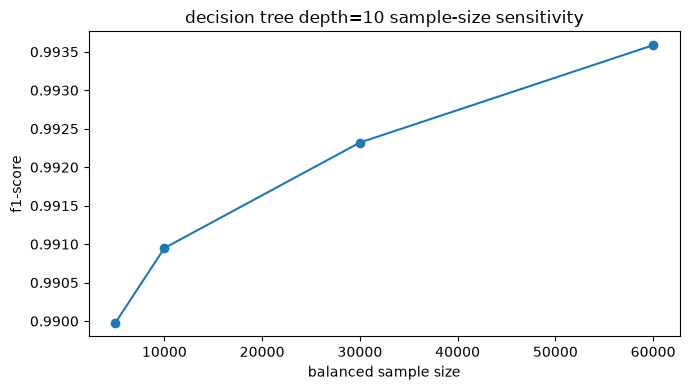

In [31]:
plt.figure(figsize=(7, 4))
plt.plot(sample_size_results_df["sample_size"], sample_size_results_df["f1_score"], marker="o")
plt.xlabel("balanced sample size")
plt.ylabel("f1-score")
plt.title("decision tree depth=10 sample-size sensitivity")
plt.tight_layout()
plt.show()

the sample-size sensitivity test strengthens the methodology because it checks whether the selected 60,000-row sample is arbitrary. if f1-score stabilises as sample size increases, it supports the decision to use the 60,000-row sample for the main experiments. if performance changes strongly, it would suggest that more data is needed before making reliable conclusions.

### 3.6 pca dimensionality reduction

In [16]:
pca = PCA(n_components=0.95, random_state=random_seed)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("original number of features:", X_train_scaled.shape[1])
print("number of pca components:", X_train_pca.shape[1])
print("explained variance retained:", round(pca.explained_variance_ratio_.sum(), 4))

original number of features: 52
number of pca components: 18
explained variance retained: 0.9518


In [17]:
start_time = time.time()

pca_knn = ScratchKNN(k=5)
pca_knn.fit(X_train_pca[:knn_train_size], y_train.iloc[:knn_train_size])

pca_knn_preds = pca_knn.predict(X_test_pca[:knn_test_size])

pca_knn_runtime = time.time() - start_time

pca_knn_result = {
    "model": "pca + scratch knn k=5",
    "accuracy": accuracy_score(y_knn_test, pca_knn_preds),
    "precision": precision_score(y_knn_test, pca_knn_preds, zero_division=0),
    "recall": recall_score(y_knn_test, pca_knn_preds, zero_division=0),
    "f1_score": f1_score(y_knn_test, pca_knn_preds, zero_division=0),
    "runtime_seconds": pca_knn_runtime
}

pca_knn_result

{'model': 'pca + scratch knn k=5',
 'accuracy': 0.9745,
 'precision': 0.9665653495440729,
 'recall': 0.9814814814814815,
 'f1_score': 0.9739663093415007,
 'runtime_seconds': 0.9854311943054199}

In [18]:
start_time = time.time()

pca_tree = DecisionTreeClassifier(
    max_depth=10,
    random_state=random_seed,
    class_weight="balanced"
)

pca_tree.fit(X_train_pca, y_train)
pca_tree_preds = pca_tree.predict(X_test_pca)

pca_tree_runtime = time.time() - start_time

pca_tree_result = {
    "model": "pca + decision tree depth=10",
    "accuracy": accuracy_score(y_test, pca_tree_preds),
    "precision": precision_score(y_test, pca_tree_preds, zero_division=0),
    "recall": recall_score(y_test, pca_tree_preds, zero_division=0),
    "f1_score": f1_score(y_test, pca_tree_preds, zero_division=0),
    "runtime_seconds": pca_tree_runtime
}

pca_tree_result

{'model': 'pca + decision tree depth=10',
 'accuracy': 0.9812222222222222,
 'precision': 0.9742663162505475,
 'recall': 0.9885555555555555,
 'f1_score': 0.9813589234502537,
 'runtime_seconds': 0.7905519008636475}

pca reduced the feature space from 52 original features to 18 principal components while retaining approximately 95.18% of the variance. this suggests that the original feature set contains redundancy, which is expected in network-flow data where several packet-length and timing features may be correlated.

## 4. results

the table below aggregates the results of every experiment described in methodology: the naive baseline (3.3), the from-scratch knn sweep over $k \in \{3,5,7\}$ (3.4), the decision tree depth sweep (3.5), and the pca-assisted knn and decision tree variants (3.6).


In [19]:
all_results = (
    [baseline_results]
    + knn_results
    + tree_results
    + [pca_knn_result, pca_tree_result]
)

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(by="f1_score", ascending=False)

results_df

,model,accuracy,precision,recall,f1_score,runtime_seconds
7,decision tree depth=None,0.997111,0.997443,0.996778,0.997110,0.755960
6,decision tree depth=10,0.993611,0.997536,0.989667,0.993586,0.554891
5,decision tree depth=5,0.983889,0.986810,0.980889,0.983840,0.419610
9,pca + decision tree depth=10,0.981222,0.974266,0.988556,0.981359,0.790552
1,scratch knn k=3,0.978000,0.973469,0.981481,0.977459,3.786096
2,scratch knn k=5,0.977000,0.969574,0.983539,0.976507,3.770695
8,pca + scratch knn k=5,0.974500,0.966565,0.981481,0.973966,0.985431
3,scratch knn k=7,0.974000,0.963710,0.983539,0.973523,3.600637
4,decision tree depth=3,0.946833,0.946684,0.947000,0.946842,0.342458
0,naive majority baseline,0.500000,0.000000,0.000000,0.000000,0.000000


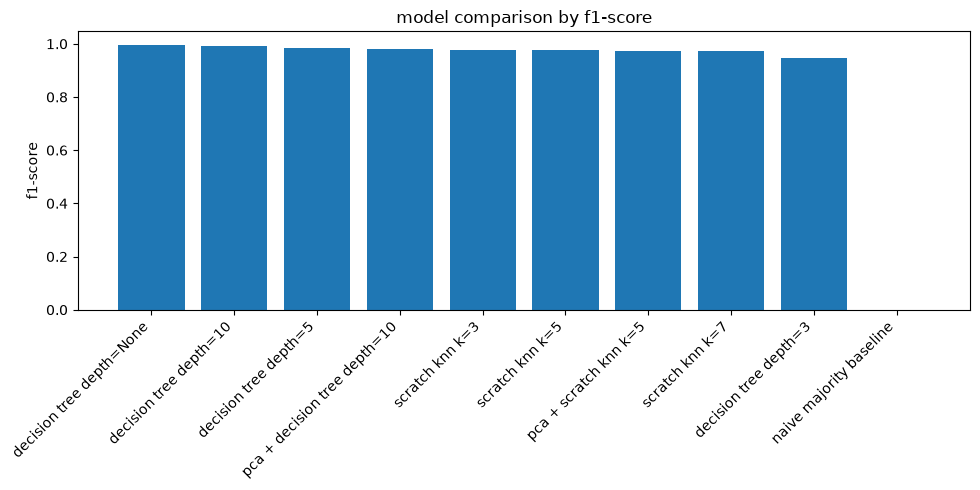

In [20]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["model"], results_df["f1_score"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("f1-score")
plt.title("model comparison by f1-score")
plt.tight_layout()
plt.show()

In [21]:
best_tree = DecisionTreeClassifier(
    max_depth=10,
    random_state=random_seed,
    class_weight="balanced"
)

best_tree.fit(X_train, y_train)
best_tree_preds = best_tree.predict(X_test)

print(classification_report(y_test, best_tree_preds))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      9000
           1       1.00      0.99      0.99      9000

    accuracy                           0.99     18000
   macro avg       0.99      0.99      0.99     18000
weighted avg       0.99      0.99      0.99     18000



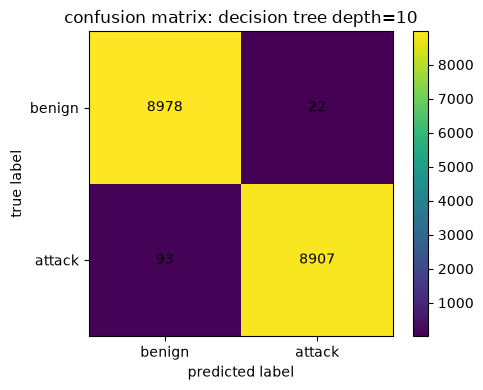

array([[8978,   22],
       [  93, 8907]])

In [22]:
cm = confusion_matrix(y_test, best_tree_preds)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("confusion matrix: decision tree depth=10")
plt.xlabel("predicted label")
plt.ylabel("true label")
plt.colorbar()

plt.xticks([0, 1], ["benign", "attack"])
plt.yticks([0, 1], ["benign", "attack"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

cm

### 4.1 error analysis

the confusion matrix gives the total number of correct and incorrect predictions, but it does not show what kinds of examples were misclassified. therefore, the false positives and false negatives are separated for further inspection. in intrusion detection, false negatives are more serious because they are malicious flows classified as benign.


In [27]:
error_analysis_df = X_test.copy()
error_analysis_df["true_label"] = y_test.values
error_analysis_df["predicted_label"] = best_tree_preds

def classify_error(row):
    if row["true_label"] == 0 and row["predicted_label"] == 1:
        return "false_positive"
    elif row["true_label"] == 1 and row["predicted_label"] == 0:
        return "false_negative"
    elif row["true_label"] == 1 and row["predicted_label"] == 1:
        return "true_positive"
    else:
        return "true_negative"

error_analysis_df["prediction_type"] = error_analysis_df.apply(classify_error, axis=1)

error_counts = error_analysis_df["prediction_type"].value_counts()
error_counts

prediction_type
true_negative     8978
true_positive     8907
false_negative      93
false_positive      22
Name: count, dtype: int64

In [28]:
top_features = feature_importance["feature"].head(5).tolist()

error_feature_summary = (
    error_analysis_df
    .groupby("prediction_type")[top_features]
    .mean()
    .round(3)
)

error_feature_summary

,Bwd Packet Length Std,Average Packet Size,Bwd Header Length,Destination Port,Max Packet Length
prediction_type,,,,,
false_negative,190.920,178.018,262.065,7567.903,680.376
false_positive,0.000,6.432,8.727,5575.227,11.545
true_negative,130.228,129.795,164.393,9554.515,519.812
true_positive,1599.649,620.675,119.567,1754.274,3737.072


the error analysis compares false positives and false negatives using the most important decision tree features. this helps identify whether the model's mistakes occur in flows with feature values close to the boundary between benign and attack traffic. the small number of false negatives shows that the depth 10 decision tree rarely misses attacks, but those missed attacks remain the most important errors from a security perspective.

### 4.2 threshold analysis: roc and precision-recall curves

accuracy, precision, recall and f1-score in the table above are all computed at the default classification threshold of 0.5. in an intrusion detection setting the cost of a missed attack (false negative) is usually much higher than the cost of a false alarm (false positive), so it is useful to examine how the decision tree's performance changes across the full range of thresholds rather than at a single fixed point. the receiver operating characteristic (roc) curve plots the true positive rate against the false positive rate as the threshold varies, and the precision-recall (pr) curve plots precision against recall directly, which is generally more informative than roc when the priority is explicitly trading off false alarms against missed attacks.


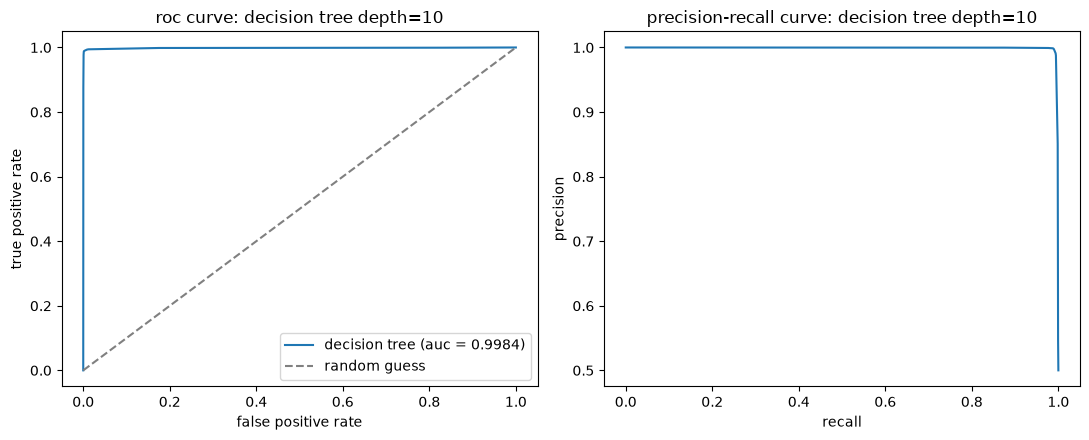

roc-auc: 0.9984


In [23]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

tree_probs = best_tree.predict_proba(X_test)[:, 1]

fpr, tpr, roc_thresholds = roc_curve(y_test, tree_probs)
roc_auc = auc(fpr, tpr)

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, tree_probs)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(fpr, tpr, label=f"decision tree (auc = {roc_auc:.4f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey", label="random guess")
axes[0].set_xlabel("false positive rate")
axes[0].set_ylabel("true positive rate")
axes[0].set_title("roc curve: decision tree depth=10")
axes[0].legend()

axes[1].plot(recall_vals, precision_vals)
axes[1].set_xlabel("recall")
axes[1].set_ylabel("precision")
axes[1].set_title("precision-recall curve: decision tree depth=10")

plt.tight_layout()
plt.show()

print("roc-auc:", round(roc_auc, 4))


**observation:** the depth 10 decision tree achieved an roc-auc of 0.9984. the roc curve rises almost immediately to a true positive rate near 1.0 while the false positive rate remains close to 0, staying pinned to the top-left corner across nearly the entire threshold range, which indicates the model separates benign and malicious traffic almost perfectly regardless of where the decision threshold is set. the precision-recall curve tells a similar story: precision remains close to 1.0 for almost the full range of recall, only dropping sharply as recall approaches 1.0, meaning the model can catch the vast majority of attacks without a meaningful increase in false alarms. this is consistent with the high f1-scores already reported in section 4 and confirms that the depth 10 tree's strong performance is not an artefact of the default 0.5 threshold specifically. if the intrusion detection system needed to prioritise recall further (minimising missed attacks) at the cost of more false alarms, the decision threshold could be lowered from the default 0.5 using the `pr_thresholds` array produced above; given how flat the precision-recall curve is until very high recall, this project's model would tolerate such a shift with little precision cost, unlike a weaker classifier where the same shift would trade away far more precision.



### f1-score confidence interval

a bootstrap confidence interval is used to estimate how much the depth 10 decision tree's f1-score might vary if a different test sample had been observed. this gives a more cautious interpretation than reporting a single test-set score.

In [29]:
rng = np.random.default_rng(random_seed)

bootstrap_scores = []
n_bootstrap = 500

y_test_array = np.asarray(y_test)
pred_array = np.asarray(best_tree_preds)

for _ in range(n_bootstrap):
    indices = rng.choice(len(y_test_array), size=len(y_test_array), replace=True)
    bootstrap_scores.append(
        f1_score(y_test_array[indices], pred_array[indices], zero_division=0)
    )

bootstrap_scores = np.array(bootstrap_scores)

ci_lower = np.percentile(bootstrap_scores, 2.5)
ci_upper = np.percentile(bootstrap_scores, 97.5)

print("bootstrap mean f1:", bootstrap_scores.mean())
print("95% confidence interval:", ci_lower, "to", ci_upper)

bootstrap mean f1: 0.993576137691797
95% confidence interval: 0.9922380023493768 to 0.9947304389651241


the bootstrap confidence interval shows that the depth 10 decision tree's f1-score is not only high, but also stable across resampled versions of the test set. this supports the conclusion that the result is reliable rather than depending on a small number of favourable test examples.

### results observation

the naive baseline achieved 50% accuracy because the dataset is balanced and the model predicts only one class. its precision, recall, and f1-score for the attack class are 0, showing that accuracy alone is not enough for intrusion detection.

all machine learning models performed substantially better than the baseline. the best scratch knn model was k=3, with an f1-score of approximately 0.977. this shows that distance-based classification can separate benign and malicious network flows, although knn is computationally expensive because each test example must be compared with stored training examples.

the decision tree models achieved the strongest overall performance. the unconstrained tree achieved the highest f1-score of approximately 0.997, while the depth 10 tree achieved approximately 0.994. the depth 10 tree was selected for detailed analysis because it balances high performance with better control over overfitting.

the pca-assisted knn model was much faster than the original scratch knn model, but its f1-score was slightly lower. the pca-assisted decision tree also performed worse than the original depth 10 decision tree. this suggests that although pca preserved most of the variance, some information useful for classification may have been weakened by the transformation.

In [24]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_tree.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
).head(10)

feature_importance

,feature,importance
11,Bwd Packet Length Std,0.405485
40,Average Packet Size,0.290262
29,Bwd Header Length,0.101156
0,Destination Port,0.067501
33,Max Packet Length,0.044958
42,Init_Win_bytes_forward,0.027865
45,min_seg_size_forward,0.009691
8,Bwd Packet Length Max,0.006527
25,Bwd IAT Std,0.006320
19,Fwd IAT Mean,0.005350


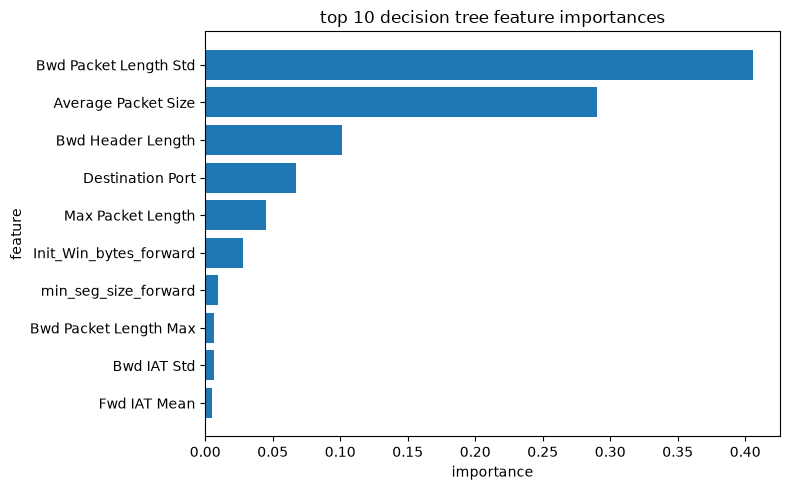

In [25]:
plt.figure(figsize=(8, 5))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.xlabel("importance")
plt.ylabel("feature")
plt.title("top 10 decision tree feature importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. evaluation

the results show that classical machine learning models can perform strongly on this balanced intrusion detection task. the naive baseline achieved only 50% accuracy and an f1-score of 0 for the attack class, confirming that a simple majority-class strategy is not useful.

the scratch knn classifier performed well, with the best version reaching an f1-score of approximately 0.977. this is a strong result, especially because the implementation was written from scratch using numpy rather than a machine learning library. however, knn was slower than the decision tree because prediction requires distance calculations against stored training examples. this makes knn less suitable for large-scale real-time intrusion detection unless approximate search or further optimisation is used.

the decision tree was the strongest model family in this project. the unconstrained decision tree achieved the highest f1-score, but it may be more likely to overfit. the depth 10 decision tree achieved an f1-score of approximately 0.994, which is only slightly lower, while remaining more controlled. the confusion matrix for the depth 10 tree showed 93 false negatives and 22 false positives out of 18,000 test examples. in an intrusion detection context, the false negatives are especially important because they represent attacks incorrectly classified as benign.

pca reduced the number of features from 52 to 18 while retaining about 95.18% of the variance. this improved the runtime of the knn experiment, but the f1-score decreased slightly. the pca decision tree also performed worse than the original depth 10 decision tree. this shows that preserving variance does not always preserve the most useful class-separating information.

there are several limitations. first, the project used a 60,000-row sample rather than the full dataset to keep runtime manageable, especially for scratch knn. second, the dataset is already balanced and preprocessed, so real deployment performance may differ on naturally imbalanced network traffic. third, only classical machine learning algorithms were compared, so the project does not test whether more advanced models such as random forests, gradient boosting, or neural networks would improve performance. finally, because this is a static dataset, it does not fully represent changing attack patterns over time.

these results are broadly consistent with the wider classical machine learning literature on cic-ids2017. maseer et al. (2021) benchmarked 31 anomaly-based intrusion detection models, including decision trees and knn, on variants of this dataset and reported f1-scores predominantly in the 0.90-1.00 range for tree-based classifiers, similar to the 0.994 achieved by the depth-10 decision tree in this project. this suggests the strong performance obtained here is not simply an artefact of this specific 60,000-row sample, but reflects a genuinely separable feature space, consistent with the roc-auc reported in section 4.1. a fairer test of generalisation, however, would be to evaluate the selected models on the full, naturally imbalanced dataset rather than the balanced sample used throughout this project, since class balancing can inflate reported f1-scores relative to a production deployment where attacks are rare. additional robustness checks were included to strengthen the evaluation. the sample-size sensitivity analysis tested whether the selected 60,000-row sample was sufficient, while the bootstrap confidence interval gave an estimate of uncertainty around the depth 10 decision tree's f1-score. the error analysis also separated false positives from false negatives, which is important because these errors have different practical consequences in intrusion detection. together, these checks make the evaluation more reliable than simply reporting one train-test split.


## 6. conclusion

this project set out to compare classical machine learning algorithms for binary network intrusion detection. the results show that the selected algorithms performed far better than the naive baseline. the scratch knn classifier demonstrated that distance-based classification can work well, but it is limited by prediction-time cost. the decision tree classifier produced the strongest results, with the depth 10 model achieving an f1-score of approximately 0.994 and strong confusion matrix performance.

pca reduced the feature space substantially, from 52 features to 18 components, but slightly reduced predictive performance. this suggests that dimensionality reduction can improve efficiency, but it should be evaluated carefully because some discarded or transformed information may still be useful for classification.

overall, the depth 10 decision tree was the best practical model in this project because it combined high accuracy, high f1-score, fast runtime, and interpretability.

## 7. references

- canadian institute for cybersecurity. cicids2017 dataset. university of new brunswick.
- pedregosa, f. et al. (2011). scikit-learn: machine learning in python. journal of machine learning research, 12, 2825-2830.
- hastie, t., tibshirani, r., and friedman, j. (2009). the elements of statistical learning. springer.
- bishop, c. m. (2006). pattern recognition and machine learning. springer.
- sharafaldin, i., habibi lashkari, a., and ghorbani, a. a. (2018). toward generating a new intrusion detection dataset and intrusion traffic characterization. proceedings of the 4th international conference on information systems security and privacy (icissp), 108-116.
- maseer, z. k., yusof, r., bahaman, n., mostafa, s. a., and mohd foozy, c. f. (2021). benchmarking of machine learning for anomaly-based intrusion detection systems in the cicids2017 dataset. ieee access, 9, 22351-22370.
